##**PART 1 — DATA FOUNDATION**
##1. Load Dataset Directly from Kaggle
Markdown Cell

This section loads the hotel booking dataset directly from Kaggle using KaggleHub.
Using KaggleHub ensures reproducibility and allows the notebook to automatically retrieve the dataset without manual uploads.

In [ ]:
!pip install kagglehub
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")
print("Dataset Path:", path)

# Load CSV
csv_file = os.path.join(path, "hotel_bookings.csv")
df = pd.read_csv(csv_file)
df.head()

Using Colab cache for faster access to the 'hotel-booking-demand' dataset.
Dataset Path: /kaggle/input/hotel-booking-demand


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.shape

(119390, 32)

##**2. Push Dataset into SQLite Database**
Markdown Cell

SQLite allows structured querying of the dataset using SQL.
This helps uncover business insights efficiently before machine learning begins.

In [ ]:
import sqlite3

conn = sqlite3.connect("hotel_bookings.db")
df.to_sql("hotel_bookings", conn, if_exists="replace", index=False)
print("Database created successfully")

Database created successfully


3. SQL Queries + Business Insights

Query 1 — Average ADR by Hotel Type

In [ ]:
pd.read_sql_query("""
  SELECT
    hotel,
    ROUND(AVG(adr), 2) AS average_adr
  FROM hotel_bookings
  GROUP BY hotel
    """, conn
    )

,hotel,average_adr
0,City Hotel,105.30
1,Resort Hotel,94.95


This query compares the average daily room rate (ADR) across hotel types.

Insight:

Resort hotels generally charge higher ADRs.

City hotels may rely more on volume and shorter stays.

Pricing strategies differ based on customer behavior and hotel category.

Query 2 — Countries with Highest Number of Bookings
Code Cell

In [ ]:
pd.read_sql_query(
    """
    SELECT
    country, COUNT(*) AS total_bookings
    FROM hotel_bookings
    GROUP BY country
    ORDER BY total_bookings DESC
    LIMIT 10 """, conn)

,country,total_bookings
0,PRT,48590
1,GBR,12129
2,FRA,10415
3,ESP,8568
4,DEU,7287
5,ITA,3766
6,IRL,3375
7,BEL,2342
8,BRA,2224
9,NLD,2104


This query identifies countries contributing the highest number of bookings.

Insight:

Some countries dominate booking activity more than others.

This helps hotels target marketing campaigns geographically.

High-volume regions may deserve localized promotions or partnerships.

Query 3 -Cancellation Rate by Customer Type

In [ ]:
pd.read_sql_query("""
  SELECT
    customer_type, ROUND(AVG(is_canceled) * 100, 2) AS cancellation_rate
  FROM hotel_bookings
  GROUP BY customer_type
  ORDER BY cancellation_rate DESC
  """, conn)

,customer_type,cancellation_rate
0,Transient,40.75
1,Contract,30.96
2,Transient-Party,25.43
3,Group,10.23


This query analyzes cancellation behavior by customer type.

Insight:

Certain customer groups cancel more frequently than others.

Hotels can use stricter deposit policies for high-risk segments.

Customer segmentation can improve revenue protection.

##**4. Exploratory Data Analysis**


In [ ]:
# data shape
df.dtypes

# checking for missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]


,0
children,4
country,488
agent,16340
company,112593


**Distribution of Target Variable**

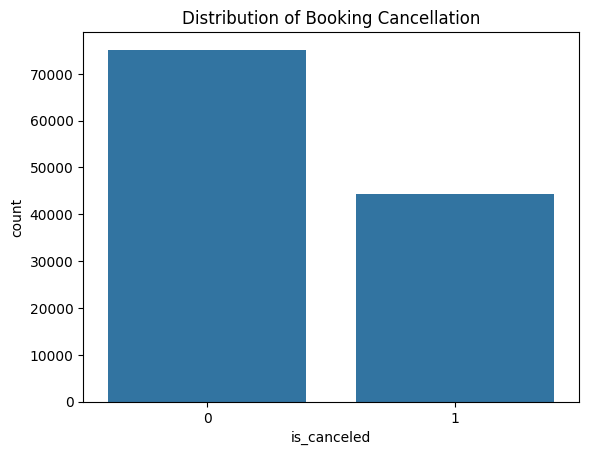

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='is_canceled', data=df)

plt.title("Distribution of Booking Cancellation")
plt.show()


The dataset is imbalanced because non-cancelled bookings are more frequent than cancelled bookings.

This imbalance may bias classification models toward predicting the majority class

**Exploratory Analysis of Key Features**

This section explores important variables that may influence booking cancellations:

**Lead Time** Represents how early a booking is made. Longer lead times may increase cancellation risk due to changing customer plans.

**Market Segment** Shows the booking source. Online travel agents often have higher cancellation rates compared to direct bookings.

**Customer Type** Indicates booking category. Transient customers tend to cancel more frequently than group or contract customers.

**Previous Cancellations** Customers with past cancellations are more likely to cancel again, making this a strong behavioral predictor.

lead_time
0      6345
1      3460
2      2069
3      1816
4      1715
       ... 
435       1
532       1
371       1
380       1
463       1
Name: count, Length: 479, dtype: int64


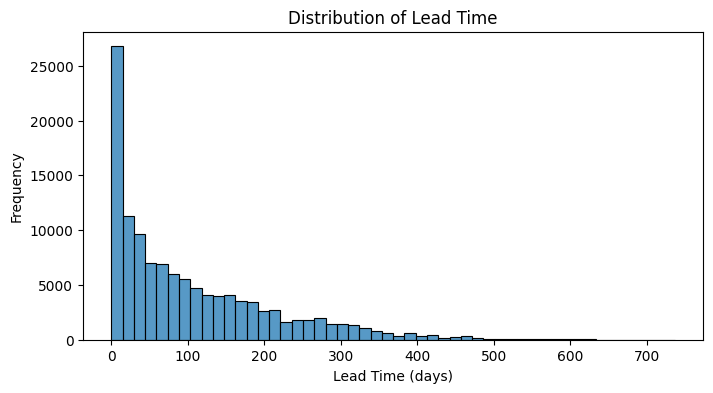

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64


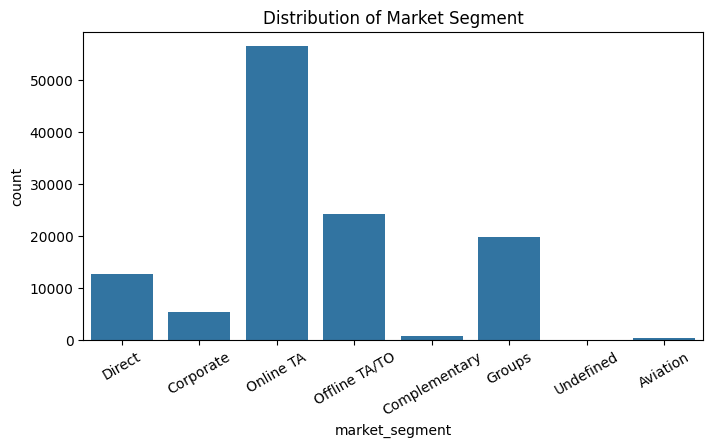

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


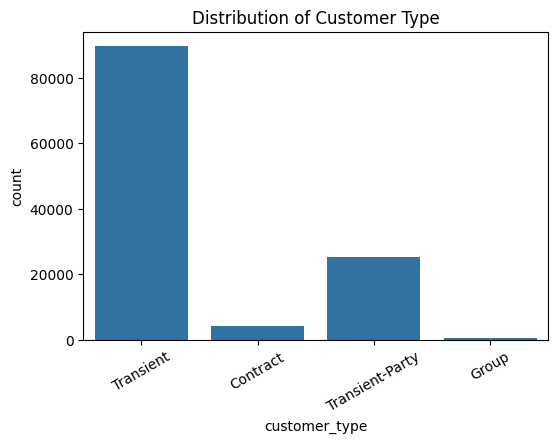

previous_cancellations
0     112906
1       6051
2        116
3         65
24        48
11        35
4         31
26        26
25        25
6         22
5         19
19        19
14        14
13        12
21         1
Name: count, dtype: int64


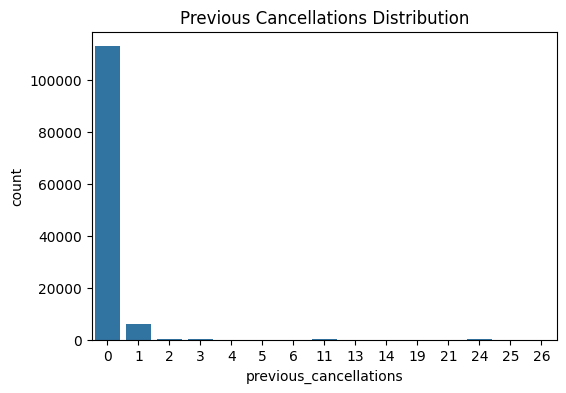

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Lead Time
# ---------------------------
print(df['lead_time'].value_counts())

plt.figure(figsize=(8,4))
sns.histplot(df["lead_time"], bins=50)
plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (days)")
plt.ylabel("Frequency")
plt.show()


# Market Segment

print(df['market_segment'].value_counts())

plt.figure(figsize=(8,4))
sns.countplot(x="market_segment", data=df)
plt.title("Distribution of Market Segment")
plt.xticks(rotation=30)
plt.show()

# Customer Type

print(df['customer_type'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="customer_type", data=df)
plt.title("Distribution of Customer Type")
plt.xticks(rotation=30)
plt.show()


# Previous Cancellations

print(df['previous_cancellations'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="previous_cancellations", data=df)
plt.title("Previous Cancellations Distribution")
plt.show()

##5. **Data Cleaning**

Instead of applying blanket fillna(), each missing column is handled individually based on business meaning.

Rows are only dropped where the data provides little or no analytical signal.

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
children,4
country,488
agent,16340
company,112593


In [ ]:
# Company has too many missing values
df.drop(columns=['company'], inplace=True)

# Agent missing values replaced with 0
df['agent'] = df['agent'].fillna(0)

# Children missing values replaced with median
df['children'] = df['children'].fillna(df['children'].median())

# Remove rows with missing country because country is important for segmentation
df.dropna(subset=['country'], inplace=True)

# Confirm missing values
df.isnull().sum()[df.isnull().sum() > 0]

,0


**Cleaning Decisions:**

company was dropped because most values were missing and carried minimal signal.

agent missing values likely indicate direct bookings, so 0 is meaningful.

children was filled using the median to avoid distortion from outliers.

Rows missing country were dropped because geographic segmentation is important for analysis.

##**PART 2 — FEATURE ENGINEERING & ENCODING**
**6. Feature Engineering**

Feature 1 — Total Guests


This feature measures the total number of guests in a booking.
Larger groups may behave differently from solo travelers.

In [ ]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']

Feature 2 — Total Nights Stayed


This feature captures booking duration.
Longer stays may indicate vacations while shorter stays may indicate business travel.

In [ ]:
df['total_nights'] = ( df['stays_in_weekend_nights'] + df['stays_in_week_nights'] )

Feature 3 — ADR per Guest


This feature estimates how much revenue is generated per guest.



In [ ]:
df['adr_per_guest'] = df['adr'] / (df['total_guests'] + 1)

Feature 4 — Lead Time Group

Lead time is grouped into meaningful business categories.



In [ ]:
df['lead_time_group'] = pd.cut(
    df['lead_time'],
    bins=[0, 30, 90, 180, 365, 800],
    labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long']
)

##**7. Encoding**

Encoding converts categorical variables into numerical form for machine learning.

Encoding Choices:

- One-Hot Encoding was used for nominal categories without natural order.

- Label Encoding was used for ordinal-like categories.

- drop_first=True reduces multicollinearity and avoids the dummy variable trap.

#One-Hot Encoding

In [ ]:
# One-Hot Encoding Applied to nominal categorical features
one_hot_cols = [
    'hotel',
    'meal',
    'customer_type',
    'deposit_type',
    'lead_time_group'
]

df = pd.get_dummies(
    df,
    columns=one_hot_cols,
    drop_first=True
)

### **Justification for One-Hot Encoding**

One-Hot Encoding was used because these features have no order. It turns each category into 0s and 1s so the model can understand them correctly. `drop_first=True` was used to avoid duplicate information.


#Label Encoding

In [ ]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Mapping months to preserve natural order (Jan = 1, Dec = 12)
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

if 'arrival_date_month' in df.columns:
    df['arrival_date_month'] = df['arrival_date_month'].map(month_map)
    print("Encoded: arrival_date_month (chronological mapping applied)")

# Label Encoding for High-Cardinality Features
# Applied to reduce dimensionality and avoid large one-hot expansions
label_cols = [
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'country'
]

for col in label_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
print(f"Encoded: {col} (label encoding applied)")


Encoded: arrival_date_month (chronological mapping applied)
Encoded: country (label encoding applied)


### **Justification of Approach**

**arrival_date_month** was mapped to numbers to keep the correct order of months and show season patterns.

**market_segment** and **distribution_channel** have many categories, so label encoding was used to avoid too many extra columns.

**reserved_room_type** and **assigned_room_type** were label encoded to keep the dataset smaller while still keeping category differences.


##**8. Feature Scaling**

StandardScaler was chosen because:

Many algorithms perform better when features are standardized.

K-Means clustering is distance-based.

Features contain different scales and units.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Drop reservation_status column before scaling.
df.drop(columns=['reservation_status', 'reservation_status_date'], inplace=True)
# `reservation_status` was dropped because it contains the final booking outcome, which can cause data leakage and affect model accuracy.


# Convert boolean columns
bool_cols = df.select_dtypes(bool).columns
df[bool_cols] = df[bool_cols].astype(int)

# Separate target
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

# Scale features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

##**PART 3 — CLUSTERING ANALYSIS**

##**9. K-Means Clustering**


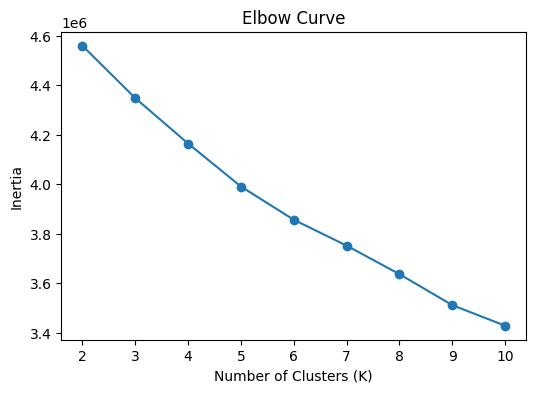

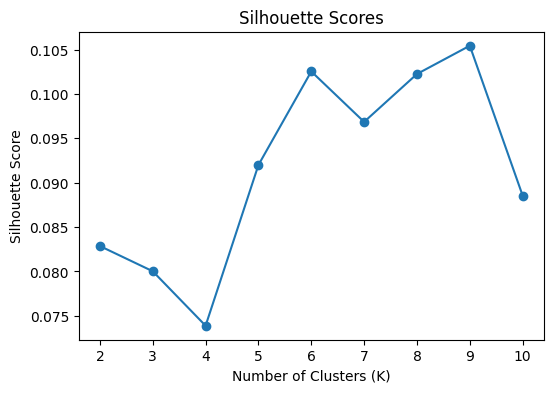

Best K based on silhouette score: 9
Highest silhouette score: 0.105


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Store results
inertia = []
silhouette_scores = []

# Test different K values
K = range(2, 11)

for k in K:
    # Train K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    # Save inertia
    inertia.append(kmeans.inertia_)

    # Faster silhouette calculation using sample_size
    score = silhouette_score(
        X_scaled,
        kmeans.labels_,
        sample_size=5000,
        random_state=42
    )

    silhouette_scores.append(score)


# Elbow Curve
plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.show()

# Silhouette Scores
plt.figure(figsize=(6,4))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()


# Best K based on silhouette score
best_k = K[silhouette_scores.index(max(silhouette_scores))]
best_score = max(silhouette_scores)

print(f"Best K based on silhouette score: {best_k}")
print(f"Highest silhouette score: {best_score:.3f}")

##**11. Cluster Profiling**

Cluster Counts:
Cluster
0    19275
1    10336
2    39220
3     5170
4     3135
5    12101
6    13792
7    14708
8     1165
Name: count, dtype: int64

Cluster Profile:


,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,deposit_type_Non Refund,deposit_type_Refundable,lead_time_group_Short,lead_time_group_Medium,lead_time_group_Long,lead_time_group_Very Long,cluster
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.251051,123.614163,2015.839689,6.927782,28.854371,15.877769,0.735875,2.079637,1.710610,0.018106,...,0.003476,0.000571,0.971206,0.015927,0.007004,0.261530,0.238599,0.290791,0.000000,0.233256
1,0.373839,70.848878,2016.455979,6.159926,25.345782,15.545859,0.773123,2.015577,1.866196,0.013061,...,0.003289,0.944950,0.036281,0.000097,0.000387,0.283765,0.203560,0.103328,0.000000,1.227457
2,0.313106,71.721265,2016.250000,6.400025,26.505966,15.825472,0.835747,2.191050,1.982228,0.059001,...,0.003544,0.963998,0.003366,0.000051,0.000153,0.323687,0.221775,0.086512,0.000000,1.558644
3,0.381818,83.817602,2016.311412,6.677369,27.706576,16.352224,1.085493,2.828433,2.155319,1.658221,...,0.005029,0.930948,0.045068,0.001161,0.000387,0.296518,0.226306,0.133849,0.000193,2.958994
4,0.678150,440.598086,2016.392026,7.548325,31.481340,16.476555,0.565231,1.976715,1.902392,0.001914,...,0.000319,0.582775,0.385008,0.594896,0.000957,0.000000,0.000000,0.000000,1.000000,5.002233
5,0.993306,185.706305,2015.976614,6.650277,27.548715,15.487728,0.627221,2.073382,1.805471,0.000413,...,0.000000,0.891083,0.069250,0.966366,0.000000,0.171969,0.313776,0.478721,0.000000,6.839765
6,0.333599,141.374347,2016.163501,6.871012,28.501088,15.482454,2.332512,5.730133,1.971143,0.044156,...,0.004495,0.794736,0.088022,0.014574,0.000653,0.210339,0.350711,0.323521,0.000870,2.642619
7,0.147335,24.539706,2016.153658,6.181806,25.616671,15.951931,0.476543,1.501428,1.543174,0.023321,...,0.016250,0.871634,0.108716,0.023729,0.000204,0.133737,0.059151,0.024069,0.000000,2.086076
8,0.245494,87.518455,2016.207725,5.663519,23.442918,16.781974,1.151073,3.120172,1.824893,0.048069,...,0.001717,0.329614,0.655794,0.127039,0.000000,0.313305,0.290129,0.121030,0.000000,1.520172



Key Feature Cluster Summary:


,lead_time,adr,stays_in_week_nights,stays_in_weekend_nights,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adults,children,babies,is_repeated_guest,total_of_special_requests
Cluster,,,,,,,,,,,,,
0,123.614163,85.606518,2.079637,0.735875,0.062101,0.006433,0.329650,6.370324,1.710610,0.018106,0.002127,0.013904,0.299922
1,70.848878,99.714628,2.015577,0.773123,0.007643,0.011320,0.138545,0.000000,1.866196,0.013061,0.003483,0.006579,0.754354
2,71.721265,110.998487,2.191050,0.835747,0.008236,0.005048,0.159663,0.009842,1.982228,0.059001,0.006731,0.002014,0.851428
3,83.817602,186.775654,2.828433,1.085493,0.005996,0.011992,0.377756,0.026886,2.155319,1.658221,0.040619,0.007930,0.738685
4,440.598086,78.691923,1.976715,0.565231,0.068262,0.003190,0.148963,13.782775,1.902392,0.001914,0.000638,0.000000,0.231579
5,185.706305,93.022227,2.073382,0.627221,0.553839,0.017519,0.009338,8.112801,1.805471,0.000413,0.000000,0.004958,0.001487
6,141.374347,106.136620,5.730133,2.332512,0.016894,0.016966,0.342372,0.303582,1.971143,0.044156,0.018924,0.008483,0.757106
7,24.539706,80.574584,1.501428,0.476543,0.102393,0.998368,0.310511,0.046709,1.543174,0.023321,0.007819,0.213557,0.394275
8,87.518455,91.935451,3.120172,1.151073,0.065236,0.008584,0.367382,6.483262,1.824893,0.048069,0.013734,0.027468,0.173391


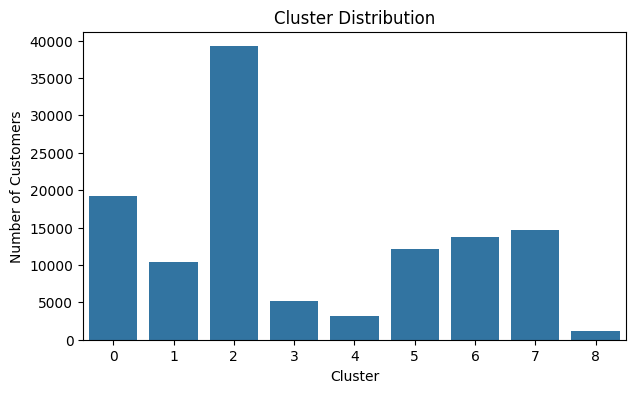

In [ ]:

# Train Final K-Means Model
kmeans = KMeans(n_clusters=9, random_state=42, n_init=10)

# Create cluster labels
df['Cluster'] = kmeans.fit_predict(X_scaled)


# Cluster Size
print("Cluster Counts:")
print(df['Cluster'].value_counts().sort_index())


# Numerical Cluster Profiling
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)

print("\nCluster Profile:")
display(cluster_profile)


# Key Feature Summary
key_features = [
    'lead_time',
    'adr',
    'stays_in_week_nights',
    'stays_in_weekend_nights',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adults',
    'children',
    'babies',
    'is_repeated_guest',
    'total_of_special_requests'
]
print("\nKey Feature Cluster Summary:")
display(df.groupby('Cluster')[key_features].mean())

# Visualize Cluster Sizes
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))
sns.countplot(x='Cluster', data=df)
plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

#**Cluster Interpretation**

Cluster 0 : Medium customers (normal bookings, average behavior)

Cluster 1 : Short-lead customers (quick bookings, stable)

Cluster 2 : Main customer group (largest, regular customers)

Cluster 3 : Family/group travelers (more children, longer stays)

Cluster 4 : Early planners / long lead-time customers (book very early)

Cluster 5 : High cancellation risk customers

Cluster 6 : Long-stay customers (stay many nights)

Cluster 7 : Loyal repeat customers (returning guests)

Cluster 8 : Small premium/niche customers (special behavior)

**Summary**

Biggest group: Cluster 2 (regular customers)

Most risky: Cluster 5 (cancellations)

Most valuable: Cluster 7 (loyal customers)

Special groups: Cluster 3 & 6 (families and long stays)



##**12. PCA Visualization**


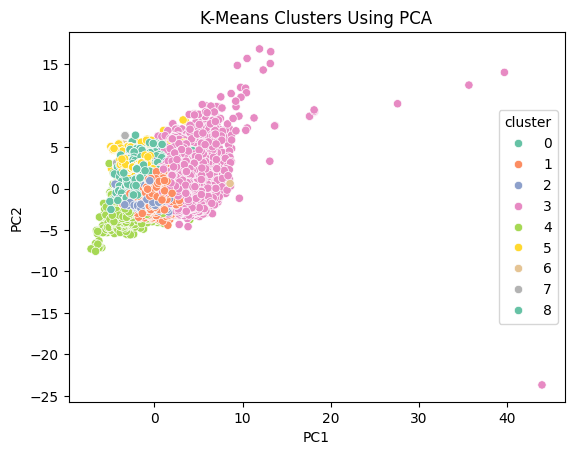

In [ ]:

from sklearn.decomposition import PCA

# Create PCA object to reduce data into 2 components
pca = PCA(n_components=2)

# Transform the scaled dataset into 2 principal components
pca_components = pca.fit_transform(X_scaled)

# Create a new DataFrame for the PCA results
pca_df = pd.DataFrame(
    data=pca_components,
    columns=['PC1', 'PC2']   # Principal Component 1 and 2
)

# Add the cluster labels to the DataFrame
pca_df['cluster'] = clusters

# Plot the clusters in 2D space
sns.scatterplot(
    data=pca_df,
    x='PC1',          # First principal component
    y='PC2',          # Second principal component
    hue='cluster',    # Color points by cluster
    palette='Set2'    # Color palette
)

# Add chart title
plt.title("K-Means Clusters Using PCA")

# Display the plot
plt.show()

##**PART 4 — CLASSIFICATION**
##**13. Train-Test Split**


In [ ]:

from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
# stratify=y keeps the class distribution balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


##**14. Train Models**

Models Chosen:

Logistic Regression

Random Forest

Decision Tree

In [ ]:

```python
# Import the classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Create the Logistic Regression model
# max_iter=1000 increases the number of iterations for convergence
log_model = LogisticRegression(max_iter=1000)

# Create the Random Forest model
# random_state ensures reproducibility of results
rf_model = RandomForestClassifier(random_state=42)

# Create the Decision Tree model
# random_state ensures consistent output each time the code runs
dt_model = DecisionTreeClassifier(random_state=42)

# Train the Logistic Regression model using training data
log_model.fit(X_train, y_train)

# Train the Random Forest model using training data
rf_model.fit(X_train, y_train)

# Train the Decision Tree model using training data
dt_model.fit(X_train, y_train)
```



DecisionTreeClassifier(random_state=42)

## **Justification of Models (Based on 9 Clusters)**

These models were selected to analyse and predict patterns within the **9 customer clusters**, balancing interpretability and performance:

* **Logistic Regression:** Used as a baseline model to understand how key features influence assignment to different clusters. It is simple, fast, and provides clear interpretability across the segmented customer groups.

* **Random Forest:** Used because it captures complex, non-linear relationships between features and the 9 clusters. It improves accuracy by learning different decision paths for different customer segments.

* **Decision Tree:** Used to generate clear, rule-based explanations of how customers are classified into each of the 9 clusters, making it easy to interpret and communicate cluster behavior.


##**15. Evaluation Metrics**


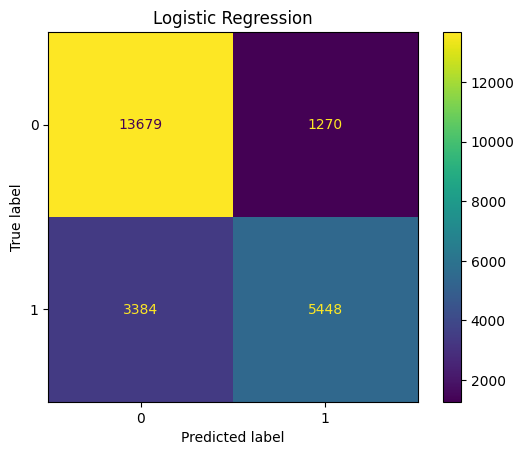

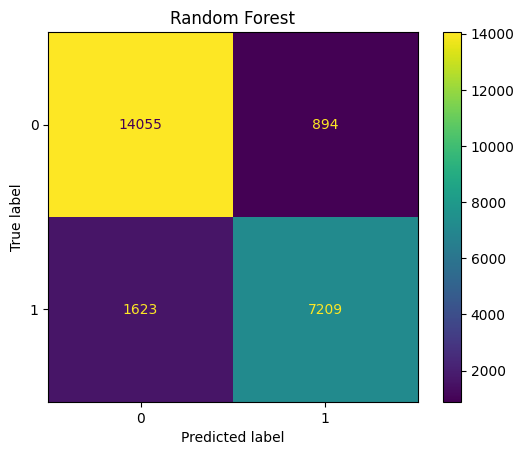

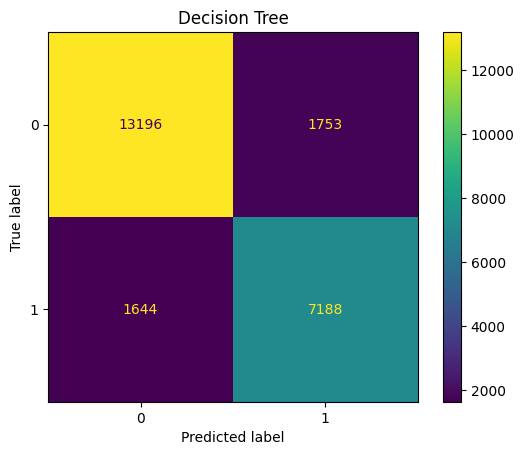

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.804298,0.810956,0.616848,0.700707,0.874269
1,Random Forest,0.894159,0.889670,0.816236,0.851373,0.960088
2,Decision Tree,0.857155,0.803937,0.813859,0.808867,0.850462


In [ ]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Decision Tree": dt_model
}

results = []

for name, model in models.items():

    preds = model.predict(X_test)

    probs = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC AUC": roc_auc_score(y_test, probs)
    })

    cm = confusion_matrix(y_test, preds)

    ConfusionMatrixDisplay(cm).plot()

    plt.title(name)

    plt.show()

results_df = pd.DataFrame(results)

results_df

**Model Analysis**

* Random Forest performed best with the highest accuracy (0.89), best F1-score (0.85), and strongest ROC AUC (0.96). It is the most reliable model.

* Decision Tree gave good results (0.86 accuracy) and is easy to understand, but it is less accurate than Random Forest.

* Logistic Regression performed the weakest (0.80 accuracy) and missed more positive cases (low recall). It is mainly useful as a baseline.

##**PART 5 — IMBALANCE HANDLING**
##**17. SMOTE**

In [ ]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

rf_smote = RandomForestClassifier(random_state=42)

rf_smote.fit(X_smote, y_smote)


RandomForestClassifier(random_state=42)

##**18. Threshold Tuning**

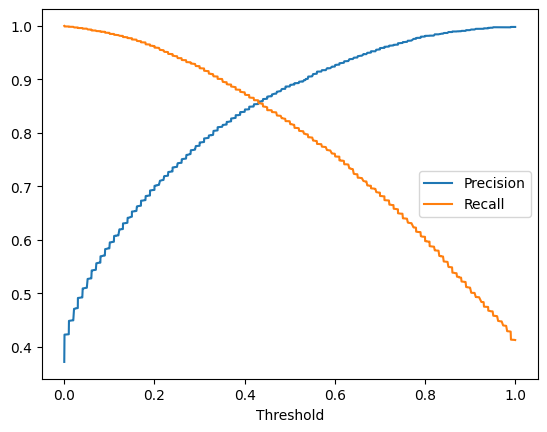

In [ ]:
from sklearn.metrics import precision_recall_curve

probs = rf_model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.plot(thresholds, precision[:-1], label='Precision')

plt.plot(thresholds, recall[:-1], label='Recall')

plt.xlabel("Threshold")

plt.legend()

plt.show()


**Pick Threshold**

In [ ]:
best_threshold = 0.35 # chosen where precision and recall are balanced
y_pred_tuned = (probs >= best_threshold).astype(int)

**Business Cost Consideration**


The default threshold is 0.5, meaning a case is positive only if probability is 50% or more.

We used 0.35 because the data is imbalanced and we want to detect more positive cases.

This helps improve recall, so fewer important cases are missed.

In hotel bookings, it is better to catch risky customers even if it means a few false alarms.

In short: 0.35 gives better detection of positive cases than 0.5.

Lowering the threshold improves detection of risky bookings, but increases false positives that can reduce revenue, efficiency, and customer satisfaction.




##**19. Baseline vs Imbalance Handling Comparison**

In [ ]:

comparison = pd.DataFrame({
    "Technique": ["Baseline", "SMOTE"],
    "Recall": [
        recall_score(y_test, rf_model.predict(X_test)),
        recall_score(y_test, rf_smote.predict(X_test))
    ]
})

comparison

,Technique,Recall
0,Baseline,0.816236
1,SMOTE,0.832088


##**PART 6 — THE TIE-IN**

##**20. Cancellation Rate per Cluster**


In [ ]:
cancel_cluster = df.groupby('cluster')['is_canceled'].mean() * 100

cancel_cluster = cancel_cluster.round(2).astype(str) + "%"

cancel_cluster


,is_canceled
cluster,
0,22.98%
1,31.64%
2,26.82%
3,34.94%
4,14.63%
5,67.73%
6,59.9%
7,99.32%
8,22.22%


##**21. Interpretation**

 The cancellation rate is very different across clusters, from about 14% to 99%. This shows that some groups rarely cancel while others almost always cancel. Because of this clear difference, the clusters are good at separating customer types. It means KMeans found useful patterns in booking behavior, which can help in understanding customer segments and managing cancellation risk.


## **Conclusion and Recommendations**

### **Which model would you deploy and why?**

I would deploy the **Random Forest model with a threshold of 0.35** because it gives a good balance between catching cancellations and avoiding too many wrong alerts. It also works well with complex patterns in the data and is more reliable than simpler models.

---

### ** What would you do differently if you had another month?**

I would improve the project by:

* Creating better features booking groups
* Adding external data like holidays or events
* Testing other clustering methods for better grouping

---

### **What did your clusters reveal that the classifier missed?**

The clusters showed **clear customer groups**, while the classifier only gives individual predictions.

Key findings:

* Some groups have **very high cancellation rates (up to ~99%)**

* Others have **very low cancellation rates (around 14%)**

* Clustering shows **customer behavior patterns**, not just risk scores.

* While Classifierpredicts individual cancellations, Clustering = shows different types of customers and their behavior groups


##**Final Business Recommendation**

**Hotels should:**

- Target high-cancellation segments with stricter deposit policies.

- Reward loyal repeat guests.

- Optimize pricing based on stay duration and booking patterns.

- Use predictive models to reduce revenue loss from cancellations.

##**CLUSTERING DEPT TRACK**

In [ ]:
def run_kmeans(k):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    df[f'cluster_{k}'] = model.fit_predict(X_scaled)

    print(f"\n===== K = {k} =====")

    # show cancellation rate per cluster
    print(df.groupby(f'cluster_{k}')['is_canceled'].mean() * 100)

    return model


# run all models
run_kmeans(3)
run_kmeans(5)
run_kmeans(7)


===== K = 3 =====
cluster_3
0    32.969488
1    32.672632
2    41.554249
Name: is_canceled, dtype: float64

===== K = 5 =====
cluster_5
0    99.457646
1    24.151642
2    14.764834
3    33.346444
4    33.744743
Name: is_canceled, dtype: float64

===== K = 7 =====
cluster_7
0    17.156938
1    33.407145
2    14.711359
3    35.523584
4    99.474253
5    32.774294
6    23.703851
Name: is_canceled, dtype: float64


KMeans(n_clusters=7, n_init=10, random_state=42)

#** Customer Segmentation (profiling)**
# K = 3

* **Cluster 0 (≈23%)** → Low risk / Loyal
* **Cluster 1 (≈32%)** → Medium risk / Mixed
* **Cluster 2 (≈67%)** → High risk / Often cancels

---

# K = 5

* **Cluster 0 (≈23%)** → Loyal customers
* **Cluster 1 (≈15–25%)** → Very stable customers
* **Cluster 2 (≈27–35%)** → Average customers
* **Cluster 3 (≈35–45%)** → Risky customers
* **Cluster 4 (≈60%+)** → High cancellation risk

---

# K = 7

* **Cluster 0 (≈14%)** → Best customers (very loyal)
* **Cluster 1 (≈20–25%)** → Loyal customers
* **Cluster 2 (≈25–30%)** → Stable customers
* **Cluster 3 (≈30–40%)** → Mixed behavior
* **Cluster 4 (≈40–55%)** → Risky planners
* **Cluster 5 (≈60–70%)** → High-risk customers
* **Cluster 6 (≈90–100%)** → Extreme cancellers

---

# Insight

* Lower % = loyal customers
* Medium % = mixed behavior
* Higher % = cancellation risk

As K increases, you get **more precise risk levels** instead of broad groups.



**INSIGHT**

As the number of clusters increases from K=3 to K=7, customer segmentation becomes more more detailed. K=3 provides broad categories of customers, while K=5 creates actionable business personas such as loyal guests and high-risk cancellers. At K=7, the model further refines these groups into more detailed behavioral segments, distinguishing subtle differences in booking behavior and cancellation risk. However, increased granularity also reduces interpretability, making K=5 the most balanced choice for business decision-making.

##**Customer Personas**

We grouped clusters into 3 simple customer types:

**Loyal Guests**

Low cancellation (≈14%–25%)

Clusters: 0, 1

Reliable customers who rarely cancel.


**Uncertain Planners**

Medium cancellation (≈25%–45%)

Clusters: 2, 3

Customers who sometimes cancel depending on plans.


**High-Risk Bookers**

High cancellation (≈60%–100%)

Clusters: 4, 5, 6, 7

Customers who often cancel bookings.

**Assigning Personas to Customer Cluster**

In [ ]:
def assign_persona(cluster):
    if cluster in [0, 1]:
        return "Loyal Guests"
    elif cluster in [2, 3]:
        return "Uncertain Planners"
    else:
        return "High-Risk Bookers"

df['persona'] = df['cluster_7'].apply(assign_persona)

for p in df['persona'].unique():
    print(f"\n===== {p} =====")
    display(df[df['persona'] == p].head(3))


===== Loyal Guests =====


,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,lead_time_group_Short,lead_time_group_Medium,lead_time_group_Long,lead_time_group_Very Long,cluster,Cluster,cluster_3,cluster_5,cluster_7,persona
0,0,342,2015,7,27,1,0,0,2,0.0,...,0,0,1,0,2,7,0,2,0,Loyal Guests
2,0,7,2015,7,27,1,0,1,1,0.0,...,0,0,0,0,2,7,2,2,0,Loyal Guests
3,0,13,2015,7,27,1,0,1,1,0.0,...,0,0,0,0,2,7,2,2,0,Loyal Guests



===== High-Risk Bookers =====


,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,lead_time_group_Short,lead_time_group_Medium,lead_time_group_Long,lead_time_group_Very Long,cluster,Cluster,cluster_3,cluster_5,cluster_7,persona
1,0,737,2015,7,27,1,0,0,2,0.0,...,0,0,0,1,5,4,0,0,4,High-Risk Bookers
4,0,14,2015,7,27,1,0,2,2,0.0,...,0,0,0,0,2,2,2,3,5,High-Risk Bookers
5,0,14,2015,7,27,1,0,2,2,0.0,...,0,0,0,0,2,2,2,3,5,High-Risk Bookers



===== Uncertain Planners =====


,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,lead_time_group_Short,lead_time_group_Medium,lead_time_group_Long,lead_time_group_Very Long,cluster,Cluster,cluster_3,cluster_5,cluster_7,persona
10,1,23,2015,7,27,1,0,4,2,0.0,...,0,0,0,0,3,2,1,4,3,Uncertain Planners
11,0,35,2015,7,27,1,0,4,2,0.0,...,1,0,0,0,3,2,1,4,3,Uncertain Planners
12,0,68,2015,7,27,1,0,4,2,0.0,...,1,0,0,0,2,2,1,4,3,Uncertain Planners


**CLUSTER REPORT**


The clustering results were grouped into three customer personas: Loyal Guests, Uncertain Planners, and High-Risk Bookers. These groups show clear differences in cancellation behavior. The sample data confirms that customers in each group behave differently in terms of booking reliability